# Симуляция задачи "Обедающие философы" с помощью сетей Петри

В этом скрипте мы моделируем классическую задачу синхронизации
"Обедающие философы" с использованием сетей Петри.
Сравниваются две модели: классическая (которая приводит к deadlock)
и модифицированная с арбитром (которая предотвращает deadlock).

## Подготовка окружения

Подключаем DrWatson для управления проектом и активируем его.

In [1]:
using DrWatson
@quickactivate "project"

Подключаем наш модуль с реализацией сетей Петри для философов.

In [2]:
include(srcdir("DiningPhilosophers.jl"))
using .DiningPhilosophers

Подключаем библиотеки для работы с таблицами, CSV, графиками и случайностью.

In [3]:
using DataFrames, CSV, Plots, Random
gr(fmt=:png)

Plots.GRBackend()

## Параметры симуляции

Количество философов — 5.

In [4]:
N = 5

5

Максимальное время симуляции — 50 единиц.

In [5]:
tmax = 50.0

50.0

## Классическая сеть (без арбитра)

In [6]:
println("=== Классическая сеть (без арбитра) ===")

=== Классическая сеть (без арбитра) ===


Строим классическую сеть Петри для N философов.

In [7]:
net_classic, u0_classic, _ = build_classical_network(N)

(Main.var"##278".DiningPhilosophers.PetriNet(20, 15, [-1 0 … 0 0; 0 -1 … 0 0; … ; 0 0 … 1 0; 0 0 … 1 1], [:Think_1, :Think_2, :Think_3, :Think_4, :Think_5, :Hungry_1, :Hungry_2, :Hungry_3, :Hungry_4, :Hungry_5, :Eat_1, :Eat_2, :Eat_3, :Eat_4, :Eat_5, :Fork_1, :Fork_2, :Fork_3, :Fork_4, :Fork_5], [:GetLeft_1, :GetLeft_2, :GetLeft_3, :GetLeft_4, :GetLeft_5, :GetRight_1, :GetRight_2, :GetRight_3, :GetRight_4, :GetRight_5, :PutForks_1, :PutForks_2, :PutForks_3, :PutForks_4, :PutForks_5]), [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0], [:Think_1, :Think_2, :Think_3, :Think_4, :Think_5, :Hungry_1, :Hungry_2, :Hungry_3, :Hungry_4, :Hungry_5, :Eat_1, :Eat_2, :Eat_3, :Eat_4, :Eat_5, :Fork_1, :Fork_2, :Fork_3, :Fork_4, :Fork_5])

Фиксируем seed для воспроизводимости результатов.

In [8]:
Random.seed!(456)

Random.TaskLocalRNG()

Запускаем стохастическую симуляцию (алгоритм Гиллеспи).

In [9]:
df_classic = simulate_stochastic(net_classic, u0_classic, tmax)

Row,time,Think_1,Think_2,Think_3,Think_4,Think_5,Hungry_1,Hungry_2,Hungry_3,Hungry_4,Hungry_5,Eat_1,Eat_2,Eat_3,Eat_4,Eat_5,Fork_1,Fork_2,Fork_3,Fork_4,Fork_5
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
2,0.174962,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
3,0.450131,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
4,0.997633,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
5,2.91918,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,2.97678,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,3.39601,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
8,4.49113,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
9,4.94763,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


Сохраняем результаты в CSV-файл.

In [10]:
CSV.write(datadir("dining_classic.csv"), df_classic)

"/home/mmulitina/work/study/2026-1/backup/2026-1-study-simulation-modeling/labs/lab05/project/data/dining_classic.csv"

Проверяем, наступил ли deadlock.

In [11]:
dead = detect_deadlock(df_classic, net_classic)
println("Deadlock обнаружен: $dead")

Deadlock обнаружен: true


Строим графики эволюции маркировки.

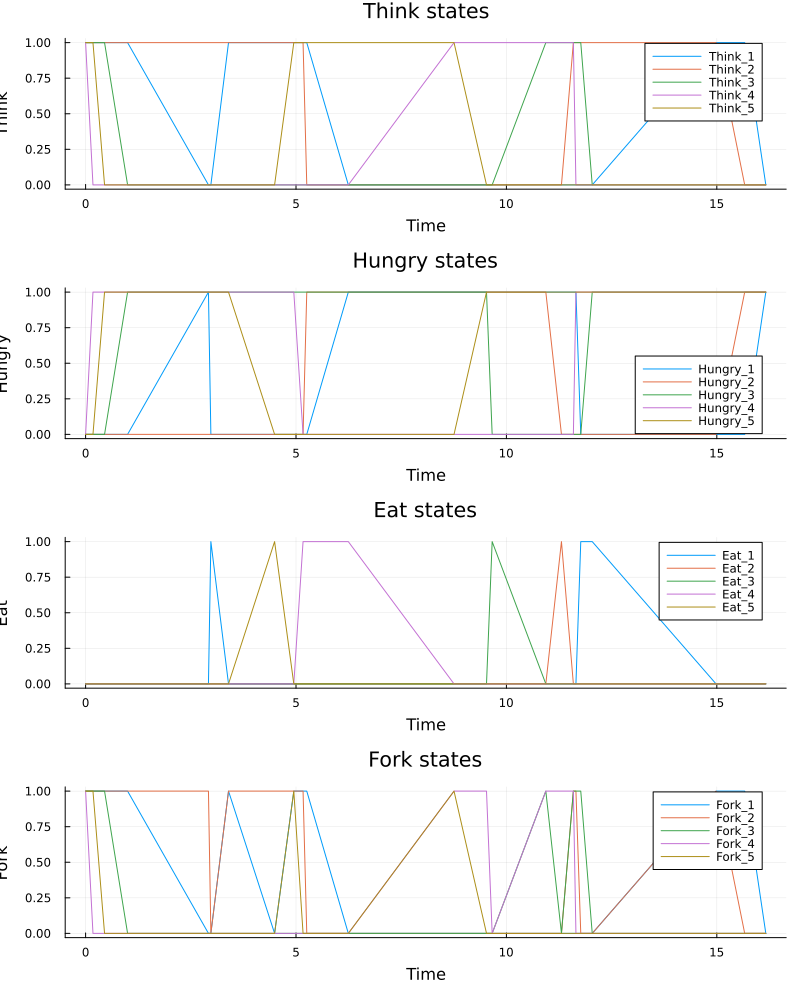

In [12]:
plot_classic = plot_marking_evolution(df_classic, N)

Сохраняем графики в файл.

In [13]:
savefig(plotsdir("classic_simulation.png"))

"/home/mmulitina/work/study/2026-1/backup/2026-1-study-simulation-modeling/labs/lab05/project/plots/classic_simulation.png"

## Сеть с арбитром

In [14]:
println("\n=== Сеть с арбитром ===")


=== Сеть с арбитром ===


Строим модифицированную сеть с арбитром.

In [15]:
net_arb, u0_arb, _ = build_arbiter_network(N)

(Main.var"##278".DiningPhilosophers.PetriNet(21, 15, [-1 0 … 0 0; 0 -1 … 0 0; … ; 0 0 … 1 1; -1 -1 … 1 1], [:Think_1, :Think_2, :Think_3, :Think_4, :Think_5, :Hungry_1, :Hungry_2, :Hungry_3, :Hungry_4, :Hungry_5  …  :Eat_2, :Eat_3, :Eat_4, :Eat_5, :Fork_1, :Fork_2, :Fork_3, :Fork_4, :Fork_5, :Arbiter], [:GetLeft_1, :GetLeft_2, :GetLeft_3, :GetLeft_4, :GetLeft_5, :GetRight_1, :GetRight_2, :GetRight_3, :GetRight_4, :GetRight_5, :PutForks_1, :PutForks_2, :PutForks_3, :PutForks_4, :PutForks_5]), [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 4.0], [:Think_1, :Think_2, :Think_3, :Think_4, :Think_5, :Hungry_1, :Hungry_2, :Hungry_3, :Hungry_4, :Hungry_5  …  :Eat_2, :Eat_3, :Eat_4, :Eat_5, :Fork_1, :Fork_2, :Fork_3, :Fork_4, :Fork_5, :Arbiter])

Запускаем стохастическую симуляцию.

In [16]:
df_arb = simulate_stochastic(net_arb, u0_arb, tmax)

Row,time,Think_1,Think_2,Think_3,Think_4,Think_5,Hungry_1,Hungry_2,Hungry_3,Hungry_4,Hungry_5,Eat_1,Eat_2,Eat_3,Eat_4,Eat_5,Fork_1,Fork_2,Fork_3,Fork_4,Fork_5,Arbiter
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,4.0
2,0.124923,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,3.0
3,0.285503,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0
4,0.367472,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
5,0.946857,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,1.45161,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2.59507,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
8,2.69306,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9,3.29849,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Сохраняем результаты.

In [17]:
CSV.write(datadir("dining_arbiter.csv"), df_arb)

"/home/mmulitina/work/study/2026-1/backup/2026-1-study-simulation-modeling/labs/lab05/project/data/dining_arbiter.csv"

Проверяем deadlock — в сети с арбитром его быть не должно.

In [18]:
dead_arb = detect_deadlock(df_arb, net_arb)
println("Deadlock обнаружен: $dead_arb")

Deadlock обнаружен: false


Строим и сохраняем графики.

In [19]:
plot_arb = plot_marking_evolution(df_arb, N)
savefig(plotsdir("arbiter_simulation.png"))

"/home/mmulitina/work/study/2026-1/backup/2026-1-study-simulation-modeling/labs/lab05/project/plots/arbiter_simulation.png"